Regression linéaire

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Chargement du dataset des stocks "Ready"
df_stocks = pd.read_csv('../data/olist_ready_stocks.csv')

# 2. Séparation des variables explicatives (X) et de la cible (y)
# Les features contiennent les ventes passées (lags), la moyenne mobile et le mois
features_stocks = ['sales_lag_1', 'sales_lag_2', 'sales_moving_avg_4', 'month']
X_stocks = df_stocks[features_stocks]
y_stocks = df_stocks['weekly_sales_volume']

# 3. Split temporel strict (80% Train / 20% Test)
split_idx = int(len(df_stocks) * 0.80)
X_train, X_test = X_stocks.iloc[:split_idx], X_stocks.iloc[split_idx:]
y_train, y_test = y_stocks.iloc[:split_idx], y_stocks.iloc[split_idx:]

print(f"📊 Données de stocks initialisées avec succès !")
print(f"Période d'entraînement : {X_train.shape[0]} semaines.")
print(f"Période de test (futur) : {X_test.shape[0]} semaines.")

📊 Données de stocks initialisées avec succès !
Période d'entraînement : 22133 semaines.
Période de test (futur) : 5534 semaines.


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# 1. Définition de la grille de paramètres à tester
param_grid_lr = {
    'fit_intercept': [True, False]
}

# 2. Configuration de la validation croisée temporelle (5 coupures successives)
tscv = TimeSeriesSplit(n_splits=5)

# 3. Recherche des meilleurs paramètres via GridSearch
grid_lr = GridSearchCV(estimator=LinearRegression(), param_grid=param_grid_lr, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_lr.fit(X_train, y_train)

# 4. Extraction du meilleur modèle optimisé
best_lr_model = grid_lr.best_estimator_
print(f"✅ Paramètre optimal trouvé pour la Régression Linéaire : {grid_lr.best_params_}")

# 5. Prédictions sur le jeu de test (le futur)
y_pred_lr = best_lr_model.predict(X_test)

# 6. Calcul des performances réelles
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("\n=== PERFORMANCES DE LA RÉGRESSION LINÉAIRE OPTIMISÉE ===")
print(f"MAE  (Erreur moyenne absolue) : {mae_lr:.2f} unités")
print(f"RMSE (Erreur quadratique)     : {rmse_lr:.2f} unités")
print(f"R²   (Variance expliquée)     : {r2_lr:.4f}")

✅ Paramètre optimal trouvé pour la Régression Linéaire : {'fit_intercept': True}

=== PERFORMANCES DE LA RÉGRESSION LINÉAIRE OPTIMISÉE ===
MAE  (Erreur moyenne absolue) : 2.19 unités
RMSE (Erreur quadratique)     : 3.98 unités
R²   (Variance expliquée)     : 0.6326


Arbre de décision

In [4]:
from sklearn.tree import DecisionTreeRegressor

# 1. Définition de la grille de paramètres à tester pour l'arbre
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10]
}

# 2. Configuration de la validation croisée temporelle (on garde la même logique)
tscv = TimeSeriesSplit(n_splits=5)

# 3. Recherche des hyperparamètres parfaits
grid_dt = GridSearchCV(estimator=DecisionTreeRegressor(random_state=42), param_grid=param_grid_dt, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_dt.fit(X_train, y_train)

# 4. Extraction du meilleur arbre de décision
best_dt_model = grid_dt.best_estimator_
print(f"✅ Paramètres optimaux trouvés pour l'Arbre de Décision : {grid_dt.best_params_}")

# 5. Prédictions sur le futur
y_pred_dt = best_dt_model.predict(X_test)

# 6. Calcul des performances
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("\n=== PERFORMANCES DE L'ARBRE DE DÉCISION OPTIMISÉ ===")
print(f"MAE  (Erreur moyenne absolue) : {mae_dt:.2f} unités")
print(f"RMSE (Erreur quadratique)     : {rmse_dt:.2f} unités")
print(f"R²   (Variance expliquée)     : {r2_dt:.4f}")

✅ Paramètres optimaux trouvés pour l'Arbre de Décision : {'max_depth': 5, 'min_samples_split': 10}

=== PERFORMANCES DE L'ARBRE DE DÉCISION OPTIMISÉ ===
MAE  (Erreur moyenne absolue) : 2.07 unités
RMSE (Erreur quadratique)     : 3.75 unités
R²   (Variance expliquée)     : 0.6746


Random forest

In [5]:
from sklearn.ensemble import RandomForestRegressor

# 1. Définition de la grille de paramètres à tester pour la forêt
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 8, 12]
}

# 2. Validation croisée temporelle
tscv = TimeSeriesSplit(n_splits=5)

# 3. Recherche des hyperparamètres parfaits
grid_rf = GridSearchCV(estimator=RandomForestRegressor(random_state=42, n_jobs=-1), param_grid=param_grid_rf, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_rf.fit(X_train, y_train)

# 4. Extraction de la meilleure forêt aléatoire
best_rf_model = grid_rf.best_estimator_
print(f"✅ Paramètres optimaux trouvés pour la Random Forest : {grid_rf.best_params_}")

# 5. Prédictions sur le futur
y_pred_rf = best_rf_model.predict(X_test)

# 6. Calcul des performances
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\n=== PERFORMANCES DE LA RANDOM FOREST OPTIMISÉE ===")
print(f"MAE  (Erreur moyenne absolue) : {mae_rf:.2f} unités")
print(f"RMSE (Erreur quadratique)     : {rmse_rf:.2f} unités")
print(f"R²   (Variance expliquée)     : {r2_rf:.4f}")

✅ Paramètres optimaux trouvés pour la Random Forest : {'max_depth': 8, 'n_estimators': 150}

=== PERFORMANCES DE LA RANDOM FOREST OPTIMISÉE ===
MAE  (Erreur moyenne absolue) : 2.02 unités
RMSE (Erreur quadratique)     : 3.60 unités
R²   (Variance expliquée)     : 0.6987


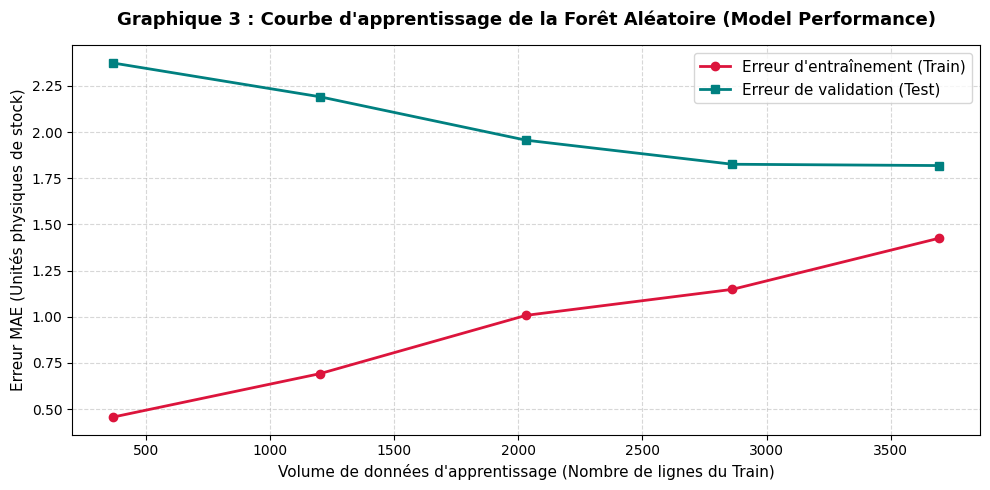

In [6]:
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit

# On s'assure d'avoir la validation temporelle sous la main
tscv = TimeSeriesSplit(n_splits=5)

# 1. Calcul de la courbe d'apprentissage (50 arbres pour aller vite au calcul)
train_sizes, train_scores, test_scores = learning_curve(
    estimator=RandomForestRegressor(max_depth=8, n_estimators=50, random_state=42, n_jobs=-1),
    X=X_train, y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# 2. Inversion du signe pour repasser en erreur positive MAE
train_errors = -train_scores.mean(axis=1)
test_errors = -test_scores.mean(axis=1)

# 3. Tracé du graphique
plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_errors, 'o-', color='crimson', linewidth=2, label='Erreur d\'entraînement (Train)')
plt.plot(train_sizes, test_errors, 's-', color='teal', linewidth=2, label='Erreur de validation (Test)')

plt.title("Graphique 3 : Courbe d'apprentissage de la Forêt Aléatoire (Model Performance)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Volume de données d'apprentissage (Nombre de lignes du Train)", fontsize=11)
plt.ylabel("Erreur MAE (Unités physiques de stock)", fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import os
import pickle

# ========================================================
# 1. ÉTAPE DE VÉRIFICATION & SAUVEGARDE EN PICKLE
# ========================================================

# On s'assure que le dossier 'models' existe (au cas où)
if not os.path.exists('models'):
    os.makedirs('models')

# Sauvegarde de la Forêt Aléatoire (best_rf_model extrait de ta recherche par grille)
with open('models/model_stocks_rf.pkl', 'wb') as f:
    pickle.dump(best_rf_model, f)

print("🎯 Super ! Le modèle 'model_stocks_rf.pkl' a été créé avec succès dans le dossier /models.")

🎯 Super ! Le modèle 'model_stocks_rf.pkl' a été créé avec succès dans le dossier /models.


: 